# **Members Info:**

## 1.   Faika Fairuz        (Id: E241412)

## 2.   Kazi Jannatul Mawa  (Id: E241426)

## 3.   Arjun Nahar Arin    (Id: E241447)



## **Dataset : https://data.mendeley.com/datasets/rn9m3zb7nt/2**

# **Import Library**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# **Import Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Datasets/Diabetes_type.csv")

display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,No. of Pregnancy,Age,BMI,BP(Systolic),BP(Diastolic),DiabetesPedigreeFunction,Insulin,Skin Thickness(mm),Type-2 Diabetic,Glucose
0,3,50,22.263762,140,90.0,0,0,317.50,1,146.0
1,1,40,24.111159,110,80.0,2,0,317.50,0,61.0
2,0,21,17.183204,120,80.0,0,0,259.08,1,97.0
3,2,30,21.244332,130,85.0,0,0,322.58,1,178.0
4,2,35,22.819490,110,75.0,0,0,335.28,1,167.0


# **Explanatory Data Analysis**

###Dataset Information

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1065 entries, 0 to 1064
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   No. of Pregnancy          1065 non-null   int64  
 1   Age                       1065 non-null   int64  
 2   BMI                       1065 non-null   float64
 3   BP(Systolic)              1065 non-null   int64  
 4   BP(Diastolic)             1061 non-null   float64
 5   DiabetesPedigreeFunction  1065 non-null   int64  
 6   Insulin                   1065 non-null   int64  
 7   Skin Thickness(mm)        1058 non-null   float64
 8   Type-2 Diabetic           1065 non-null   int64  
 9   Glucose                   1065 non-null   float64
dtypes: float64(4), int64(6)
memory usage: 83.3 KB
None


### Descriptive Statistics

In [ ]:
display(df.describe())

,No. of Pregnancy,Age,BMI,BP(Systolic),BP(Diastolic),DiabetesPedigreeFunction,Insulin,Skin Thickness(mm),Type-2 Diabetic,Glucose
count,1065.000000,1065.000000,1065.000000,1065.000000,1061.000000,1065.000000,1065.000000,1058.000000,1065.000000,1065.000000
mean,3.114554,44.467606,25.246733,119.350235,79.829406,1.487324,5.406573,307.242769,0.788732,138.448920
std,1.878355,12.695950,3.800444,14.289513,10.770160,1.560822,8.879252,35.366131,0.408400,64.832444
min,0.000000,21.000000,17.183204,80.000000,30.000000,0.000000,0.000000,29.210000,0.000000,50.000000
25%,2.000000,35.000000,22.650587,110.000000,70.000000,0.000000,0.000000,287.020000,1.000000,80.000000
50%,3.000000,44.000000,24.603224,120.000000,80.000000,1.000000,0.000000,304.800000,1.000000,129.000000
75%,4.000000,53.000000,27.492665,130.000000,80.000000,2.000000,12.000000,330.200000,1.000000,178.000000
max,12.000000,86.000000,37.442807,180.000000,120.000000,8.000000,44.000000,406.400000,1.000000,450.000000


### Missing Values Check

In [ ]:
print(df.isnull().sum())

No. of Pregnancy            0
Age                         0
BMI                         0
BP(Systolic)                0
BP(Diastolic)               4
DiabetesPedigreeFunction    0
Insulin                     0
Skin Thickness(mm)          7
Type-2 Diabetic             0
Glucose                     0
dtype: int64


### Percentage of Missing Values

In [ ]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

display(missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

,Missing Count,Missing Percentage
Skin Thickness(mm),7,0.657277
BP(Diastolic),4,0.375587


#### Rows Containing Missing Data

In [ ]:
display(df[df.isnull().any(axis=1)])

,No. of Pregnancy,Age,BMI,BP(Systolic),BP(Diastolic),DiabetesPedigreeFunction,Insulin,Skin Thickness(mm),Type-2 Diabetic,Glucose
14,2,36,20.411221,110,NaN,0,0,304.8,0,140.0
44,4,30,20.037386,120,80.0,0,0,NaN,0,62.0
86,2,40,24.111159,120,NaN,3,0,304.8,1,90.0
92,2,32,21.373211,110,80.0,0,0,NaN,1,150.0
133,3,35,25.384279,120,NaN,1,0,317.5,0,155.0
174,2,35,28.847280,120,NaN,1,0,317.5,0,68.0
380,2,40,24.993331,110,60.0,0,0,NaN,1,120.0
517,0,23,27.727443,110,80.0,0,22,NaN,1,190.0
604,5,50,24.993331,110,60.0,3,0,NaN,1,150.0
962,2,30,22.177464,140,110.0,1,0,NaN,1,140.0


### Visualizing Distributions of Numerical Features

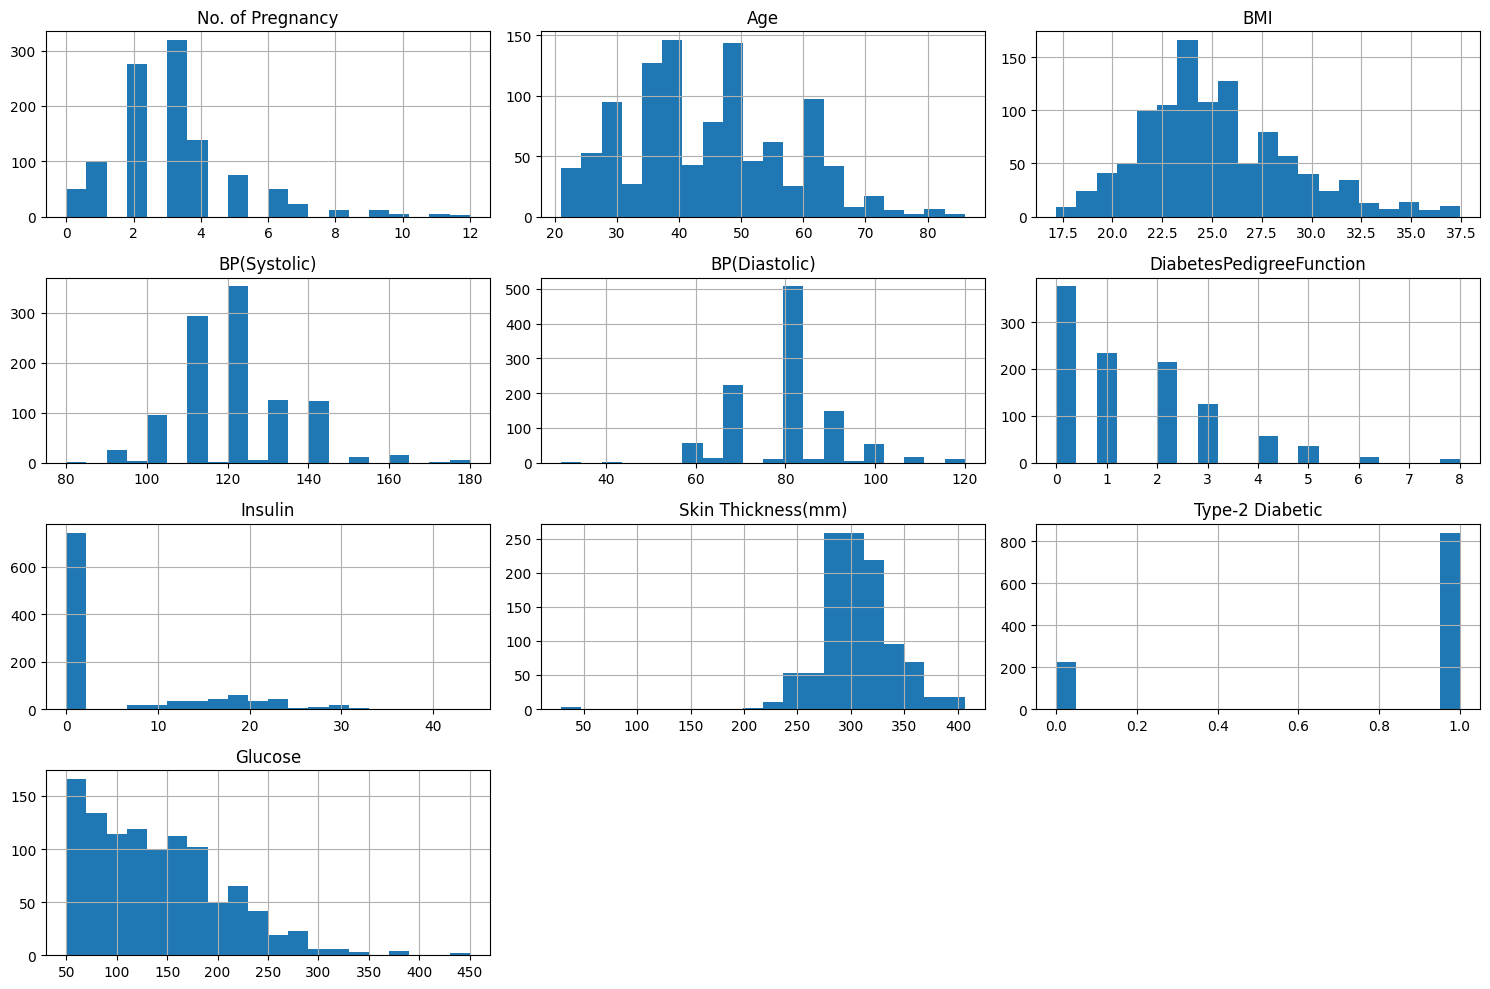

In [ ]:
df.hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.show()

### Correlation Matrix (for numerical features)

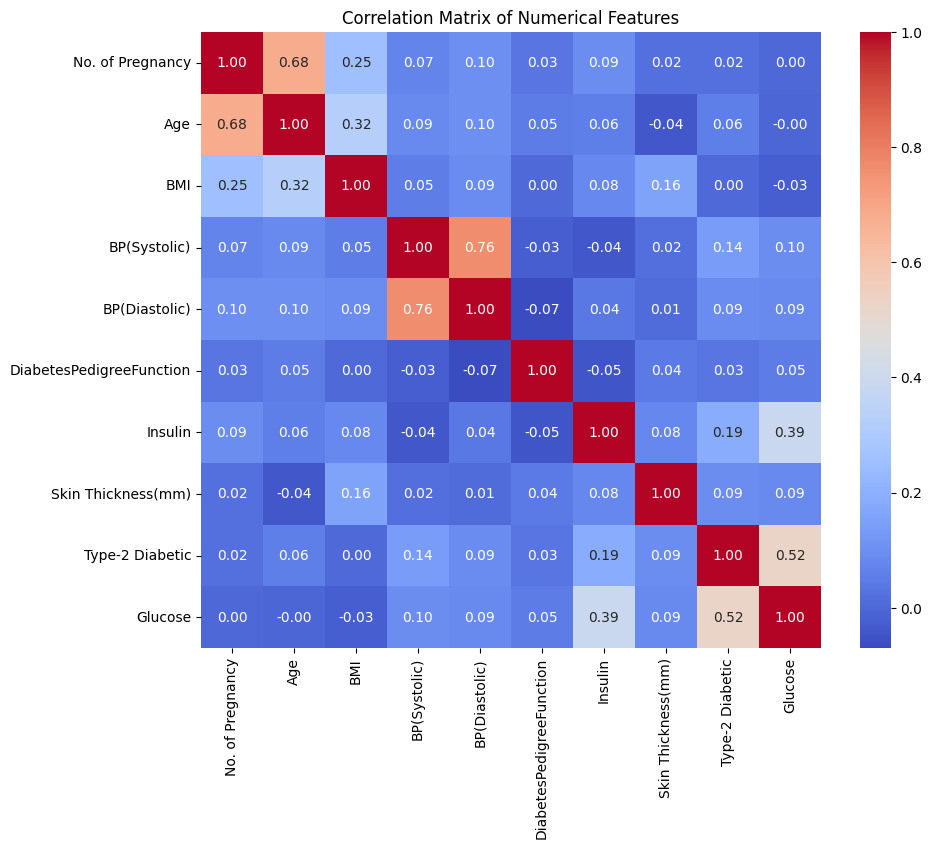

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# **Checking NaN and Imputation of Missing Values**

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
imputer.fit(df[['BP(Diastolic)', 'Skin Thickness(mm)']])
df[['BP(Diastolic)', 'Skin Thickness(mm)']] = imputer.transform(df[['BP(Diastolic)', 'Skin Thickness(mm)']])

print("Missing values after imputation:")
display(df.isnull().sum())

Missing values after imputation:


,0
No. of Pregnancy,0
Age,0
BMI,0
BP(Systolic),0
BP(Diastolic),0
DiabetesPedigreeFunction,0
Insulin,0
Skin Thickness(mm),0
Type-2 Diabetic,0
Glucose,0


In [ ]:
df.duplicated().sum()/len(df)*100

np.float64(53.6150234741784)

# **Checking Dataset Balance (Target Variable Distribution)**

Distribution of 'Type-2 Diabetic':


,count
Type-2 Diabetic,
1,840
0,225



Percentage distribution of 'Type-2 Diabetic':


,proportion
Type-2 Diabetic,
1,78.873239
0,21.126761


/tmp/ipykernel_42738/1160171389.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Type-2 Diabetic', data=df, palette='viridis')


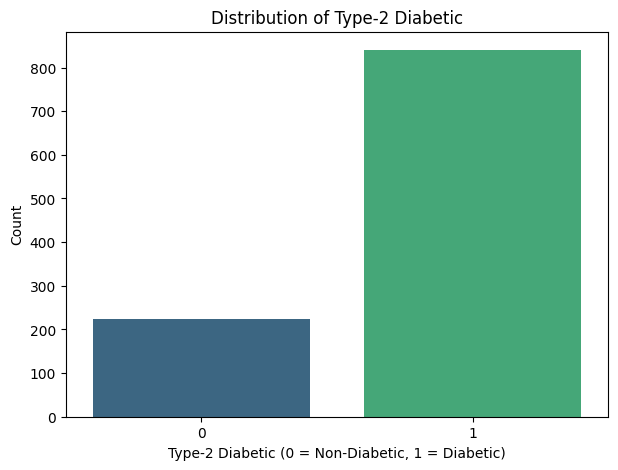

In [ ]:
print("Distribution of 'Type-2 Diabetic':")
display(df['Type-2 Diabetic'].value_counts())

print("\nPercentage distribution of 'Type-2 Diabetic':")
display(df['Type-2 Diabetic'].value_counts(normalize=True) * 100)

plt.figure(figsize=(7, 5))
sns.countplot(x='Type-2 Diabetic', data=df, palette='viridis')
plt.title('Distribution of Type-2 Diabetic')
plt.xlabel('Type-2 Diabetic (0 = Non-Diabetic, 1 = Diabetic)')
plt.ylabel('Count')
plt.show()

# **Handling Imbalanced Data with SMOTE**

In [ ]:
from imblearn.over_sampling import SMOTE

# Define features (X) and target (y)
X = df.drop('Type-2 Diabetic', axis=1)
y = df['Type-2 Diabetic']

# Instantiate SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Original training target distribution:", y.value_counts())

print("\nResampled training target distribution:", y_resampled.value_counts())

Original training target distribution: Type-2 Diabetic
1    840
0    225
Name: count, dtype: int64

Resampled training target distribution: Type-2 Diabetic
1    840
0    840
Name: count, dtype: int64


/tmp/ipykernel_42738/2741266956.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_resampled, palette='viridis')


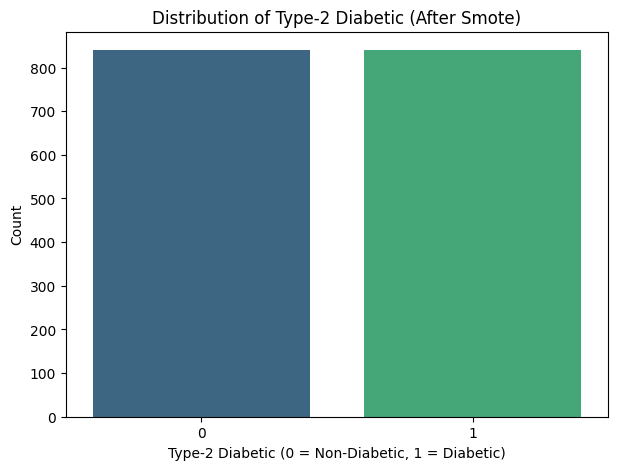

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(x=y_resampled, palette='viridis')
plt.title('Distribution of Type-2 Diabetic (After Smote)')
plt.xlabel('Type-2 Diabetic (0 = Non-Diabetic, 1 = Diabetic)')
plt.ylabel('Count')
plt.show()

#**Outlier Detection**

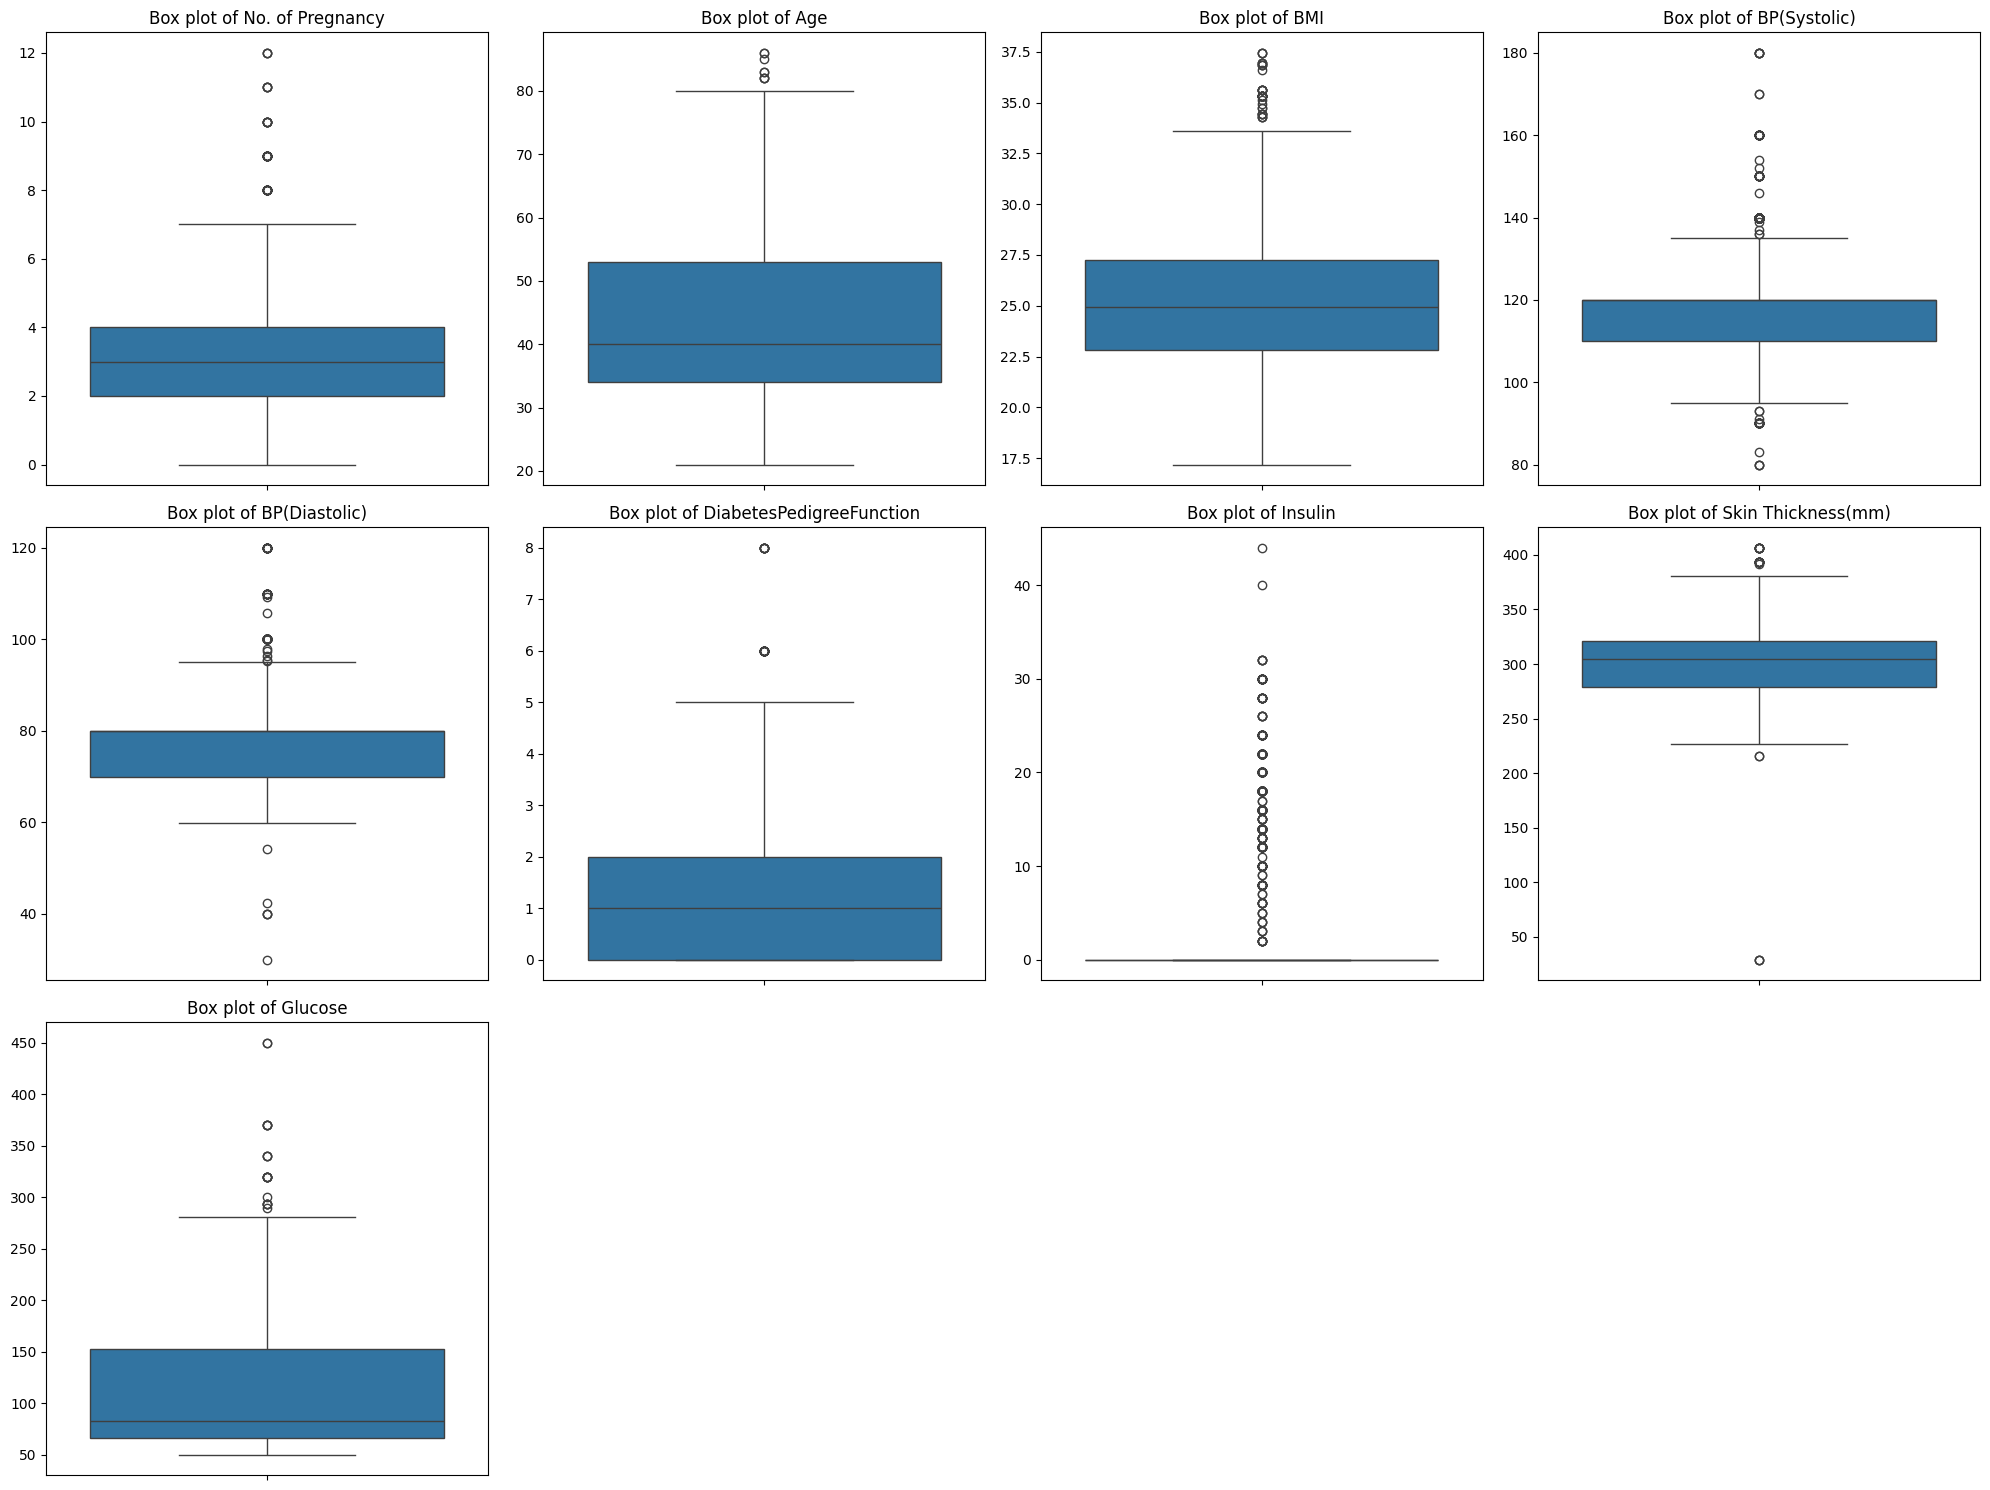

In [ ]:
plt.figure(figsize=(20, 15))
for i, column in enumerate(X_resampled.columns):
    plt.subplot(3, 4,  i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=X_resampled[column])
    plt.title(f'Box plot of {column}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

## **Quantifying Outliers**

In [ ]:
for column in X_resampled.columns:
    Q1 = X_resampled[column].quantile(0.25)
    Q3 = X_resampled[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = X_resampled[(X_resampled[column] < lower_bound) | (X_resampled[column] > upper_bound)]
    outlier_percentage = (len(outliers) / len(X_resampled)) * 100
    print(f"Column '{column}': {outlier_percentage:.2f}% outliers")

Column 'No. of Pregnancy': 2.92% outliers
Column 'Age': 0.48% outliers
Column 'BMI': 2.32% outliers
Column 'BP(Systolic)': 13.99% outliers
Column 'BP(Diastolic)': 5.89% outliers
Column 'DiabetesPedigreeFunction': 1.61% outliers
Column 'Insulin': 24.52% outliers
Column 'Skin Thickness(mm)': 1.43% outliers
Column 'Glucose': 1.25% outliers


## **Outlier Handling Strategy**

For outlier handling, we will adopt a strategy that considers the percentage of outliers in each feature:

* **Removal:** Deleting rows or columns with outliers (can lead to data loss).

* **Transformation:** Applying mathematical transformations (e.g., log, square root) to reduce the impact of extreme values.

* **Imputation/Capping:** Replacing outliers with a specific value (e.g., mean, median, or values at a certain percentile like the 5th and 95th).

* **Model-based methods:** Using algorithms like Isolation Forest or One-Class SVM to detect and potentially remove or adjust outliers. Isolation Forest is particularly good for high-dimensional data and works by isolating observations that are few and different from the rest.

## **Outlier Handling: Capping(Winsorization)**

Based on the calculated outlier percentages BP(Systolic): 13.99% outliers, BP(Diastolic): 5.89% outliers and Insulin: 24.52% outliers by establishing an acceptance range of 5%, we will apply capping using the Interquartile Range (IQR) method. This involves replacing any value below the lower bound with the lower bound, and any value above the upper bound with the upper bound.

In [ ]:
# Identify columns with more than 5% outliers to apply capping
outlier_columns = ['BP(Systolic)', 'BP(Diastolic)', 'Insulin']

for column in outlier_columns:
    Q1 = X_resampled[column].quantile(0.25)
    Q3 = X_resampled[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Apply capping
    X_resampled[column] = np.where(X_resampled[column] < lower_bound, lower_bound, X_resampled[column])
    X_resampled[column] = np.where(X_resampled[column] > upper_bound, upper_bound, X_resampled[column])

    print(f"Outliers in '{column}' capped between {lower_bound:.2f} and {upper_bound:.2f}")

Outliers in 'BP(Systolic)' capped between 95.00 and 135.00
Outliers in 'BP(Diastolic)' capped between 55.00 and 95.00
Outliers in 'Insulin' capped between 0.00 and 0.00


##**Re-quantify Outliers After Capping**

In [ ]:
# Re-quantify outliers to show the effect of capping for all columns
for column in X_resampled.columns:
    Q1 = X_resampled[column].quantile(0.25)
    Q3 = X_resampled[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = X_resampled[(X_resampled[column] < lower_bound) | (X_resampled[column] > upper_bound)]
    outlier_percentage = (len(outliers) / len(X_resampled)) * 100
    print(f"Column '{column}': {outlier_percentage:.2f}% outliers")

Column 'No. of Pregnancy': 2.92% outliers
Column 'Age': 0.48% outliers
Column 'BMI': 2.32% outliers
Column 'BP(Systolic)': 0.00% outliers
Column 'BP(Diastolic)': 0.00% outliers
Column 'DiabetesPedigreeFunction': 1.61% outliers
Column 'Insulin': 0.00% outliers
Column 'Skin Thickness(mm)': 1.43% outliers
Column 'Glucose': 1.25% outliers


# **Re-checking Dataset Balance After Outlier Handling**

Resampled training target distribution (counts): Type-2 Diabetic
1    840
0    840
Name: count, dtype: int64

Resampled training target distribution ([Percentage]): Type-2 Diabetic
1    50.0
0    50.0
Name: proportion, dtype: float64


/tmp/ipykernel_42738/1403468721.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_resampled, palette='viridis')


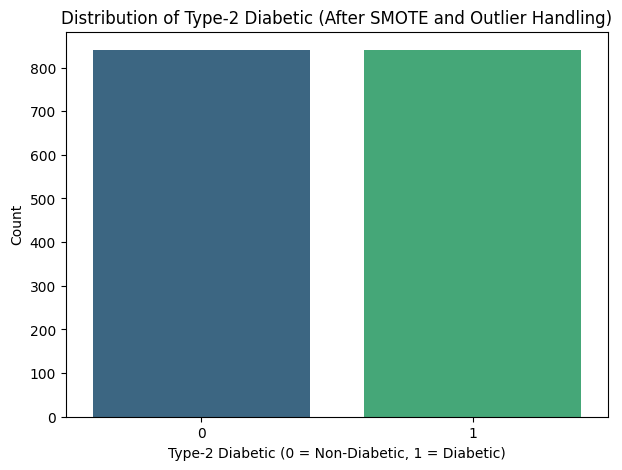

In [ ]:
print("Resampled training target distribution (counts):", y_resampled.value_counts())
print("\nResampled training target distribution ([Percentage]):", y_resampled.value_counts(normalize=True) * 100)

plt.figure(figsize=(7, 5))
sns.countplot(x=y_resampled, palette='viridis')
plt.title('Distribution of Type-2 Diabetic (After SMOTE and Outlier Handling)')
plt.xlabel('Type-2 Diabetic (0 = Non-Diabetic, 1 = Diabetic)')
plt.ylabel('Count')
plt.show()

# **Train-Test Split**

Now, we'll split our resampled data (`X_resampled`, `y_resampled`) into training and testing sets. This is essential for evaluating the performance of our machine learning models on unseen data. A common split ratio is 80% for training and 20% for testing.

In [ ]:
print(f"Shape of X_resampled: {X_resampled.shape}")
print(f"Shape of y_resampled: {y_resampled.shape}")

Shape of X_resampled: (1680, 9)
Shape of y_resampled: (1680,)


In [ ]:
# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribution of target variable in training set:")
display(y_train.value_counts(normalize=True) * 100)

print("\nDistribution of target variable in test set:")
display(y_test.value_counts(normalize=True) * 100)

X_train shape: (1344, 9)
X_test shape: (336, 9)
y_train shape: (1344,)
y_test shape: (336,)

Distribution of target variable in training set:


,proportion
Type-2 Diabetic,
1,50.0
0,50.0



Distribution of target variable in test set:


,proportion
Type-2 Diabetic,
0,50.0
1,50.0


# **Feature Scaling**

Feature scaling is important for many machine learning algorithms, especially those that calculate distances between data points (like KNN or SVM) or rely on gradient descent (like neural networks). We will use `StandardScaler` to transform our features so they have a mean of 0 and a standard deviation of 1. It's crucial to fit the scaler only on the training data to prevent data leakage.

In [ ]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame (optional, but good for readability and consistency)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Scaled Training Features (first 5 rows):")
display(X_train_scaled.head())

print("\n\nScaled Testing Features (first 5 rows):")
display(X_test_scaled.head())

Scaled Training Features (first 5 rows):


,No. of Pregnancy,Age,BMI,BP(Systolic),BP(Diastolic),DiabetesPedigreeFunction,Insulin,Skin Thickness(mm),Glucose
0,-0.500645,-0.639417,-1.050447,0.245642,0.130517,-0.232621,0.0,0.248384,0.152123
1,-1.520912,-1.308251,1.763779,-1.599244,0.130517,-0.889434,0.0,1.397815,-0.780193
2,1.539890,0.921194,-0.584811,0.245642,0.130517,-0.232621,0.0,-0.364646,0.425389
3,0.009489,-0.639417,-0.186169,0.245642,0.130517,1.737817,0.0,0.401641,0.409314
4,-0.500645,-0.267843,-0.075070,-0.676801,0.130517,-0.889434,0.0,-0.517904,-0.731970




Scaled Testing Features (first 5 rows):


,No. of Pregnancy,Age,BMI,BP(Systolic),BP(Diastolic),DiabetesPedigreeFunction,Insulin,Skin Thickness(mm),Glucose
0,0.009489,1.961602,-0.075070,-0.676801,-2.147262,-0.889434,0.0,-0.747790,-0.812342
1,-1.520912,-1.308251,1.763779,-1.599244,0.130517,-0.889434,0.0,1.397815,-0.780193
2,0.009489,0.400990,-0.064669,0.245642,0.130517,-0.889434,0.0,0.401641,-0.105067
3,-0.500645,-0.862362,-0.444397,-1.599244,-1.008373,-0.232621,0.0,0.518744,-0.784891
4,-0.500645,-0.416473,-0.511982,0.245642,0.130517,1.737817,0.0,-0.747790,1.711342


# **Model Training and Evaluation**

Now, we will train and evaluate several machine learning classification models on our prepared dataset (`X_train_scaled_df`, `y_train`, `X_test_scaled_df`, `y_test`). We will use various metrics to assess their performance, including accuracy, classification reports (precision, recall, f1-score), and confusion matrices.

In [ ]:
model_performance = {}

In [ ]:
# 1. Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_report = classification_report(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print("\nLogistic Regression Classification Report:\n", lr_report)
print("\nLogistic Regression Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
model_performance['Logistic Regression']= {'Accuracy': lr_accuracy, 'Report': classification_report(y_test, y_pred_lr, output_dict=True)}

Logistic Regression Accuracy: 0.8631

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87       168
           1       0.90      0.82      0.86       168

    accuracy                           0.86       336
   macro avg       0.87      0.86      0.86       336
weighted avg       0.87      0.86      0.86       336


Logistic Regression Confusion Matrix:
 [[153  15]
 [ 31 137]]


In [ ]:
# 2. K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_report = classification_report(y_test, y_pred_knn)
print(f"KNN Accuracy: {knn_accuracy:.4f}")
print("\nKNN Classification Report:\n", knn_report)
print("\nKNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
model_performance['KNN']= {'Accuracy': knn_accuracy, 'Report': classification_report(y_test, y_pred_knn, output_dict=True)}

KNN Accuracy: 0.9167

KNN Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.95      0.92       168
           1       0.95      0.88      0.91       168

    accuracy                           0.92       336
   macro avg       0.92      0.92      0.92       336
weighted avg       0.92      0.92      0.92       336


KNN Confusion Matrix:
 [[160   8]
 [ 20 148]]


In [ ]:
# 3. Support Vector Machine (SVM)
from sklearn.svm import SVC

svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_report = classification_report(y_test, y_pred_svm)
print(f"SVM Accuracy: {svm_accuracy:.4f}")
print("\nSVM Classification Report:\n", svm_report)
print("\nSVM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
model_performance['SVM']= {'Accuracy': svm_accuracy, 'Report': classification_report(y_test, y_pred_svm, output_dict=True)}

SVM Accuracy: 0.9107

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.91       168
           1       0.92      0.90      0.91       168

    accuracy                           0.91       336
   macro avg       0.91      0.91      0.91       336
weighted avg       0.91      0.91      0.91       336


SVM Confusion Matrix:
 [[154  14]
 [ 16 152]]


In [ ]:
# 4. Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_report = classification_report(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print("\nDecision Tree Classification Report:\n", dt_report)
print("\nDecision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
model_performance['Decision Tree']= {'Accuracy': dt_accuracy, 'Report': classification_report(y_test, y_pred_dt, output_dict=True)}

Decision Tree Accuracy: 0.9405

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.92      0.94       168
           1       0.92      0.96      0.94       168

    accuracy                           0.94       336
   macro avg       0.94      0.94      0.94       336
weighted avg       0.94      0.94      0.94       336


Decision Tree Confusion Matrix:
 [[154  14]
 [  6 162]]


In [ ]:
# 5. Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_report = classification_report(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print("\nRandom Forest Classification Report:\n", rf_report)
print("\nRandom Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
model_performance['Random Forest']= {'Accuracy': rf_accuracy, 'Report': classification_report(y_test, y_pred_rf, output_dict=True)}

Random Forest Accuracy: 0.9673

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.94      0.97       168
           1       0.94      0.99      0.97       168

    accuracy                           0.97       336
   macro avg       0.97      0.97      0.97       336
weighted avg       0.97      0.97      0.97       336


Random Forest Confusion Matrix:
 [[158  10]
 [  1 167]]


In [ ]:
# 6. Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_scaled, y_train)

y_pred_gb = gb_model.predict(X_test_scaled)

gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_report = classification_report(y_test, y_pred_gb)
print(f"Gradient Boosting Accuracy: {gb_accuracy:.4f}")
print("\nGradient Boosting Classification Report:\n", gb_report)
print("\nCGradient Boosting onfusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
model_performance['Gradient Boosting']= {'Accuracy': gb_accuracy, 'Report': classification_report(y_test, y_pred_gb, output_dict=True)}

Gradient Boosting Accuracy: 0.9524

Gradient Boosting Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.92      0.95       168
           1       0.92      0.99      0.95       168

    accuracy                           0.95       336
   macro avg       0.95      0.95      0.95       336
weighted avg       0.95      0.95      0.95       336


CGradient Boosting onfusion Matrix:
 [[154  14]
 [  2 166]]


In [ ]:
# 7. XGBoost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_report = classification_report(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")
print("\nXGBoost Classification Report:\n", xgb_report)
print("\nXGBoost Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
model_performance['XGBoost']= {'Accuracy': xgb_accuracy, 'Report': classification_report(y_test, y_pred_xgb, output_dict=True)}

XGBoost Accuracy: 0.9613

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.93      0.96       168
           1       0.94      0.99      0.96       168

    accuracy                           0.96       336
   macro avg       0.96      0.96      0.96       336
weighted avg       0.96      0.96      0.96       336


XGBoost Confusion Matrix:
 [[157  11]
 [  2 166]]


In [ ]:
# 8. LightGBM
import lightgbm as lgb

lgbm_model = lgb.LGBMClassifier(random_state=42)
lgbm_model.fit(X_train_scaled, y_train)

y_pred_lgbm = lgbm_model.predict(X_test_scaled)

lgbm_accuracy = accuracy_score(y_test, y_pred_lgbm)
lgbm_report = classification_report(y_test, y_pred_lgbm)
print(f"\nLightGBM Accuracy: {lgbm_accuracy:.4f}")
print("\nLightGBM Classification Report:\n", lgbm_report)
print("\nLightGBM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lgbm))
model_performance['LightGBM']= {'Accuracy': lgbm_accuracy, 'Report': classification_report(y_test, y_pred_lgbm, output_dict=True)}

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 672, number of negative: 672
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000194 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 780
[LightGBM] [Info] Number of data points in the train set: 1344, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

LightGBM Accuracy: 0.9702

LightGBM Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97       168
           1      

##**Model Performance Summary**



In [ ]:
for model_name, metrices in model_performance.items():
  print(f"\n{model_name}:")
  print(f"  Accuracy: {metrices['Accuracy']:.4f}")
  print(f"  Precision(class 1): {metrices['Report']['1']['precision']:.4f}")
  print(f"  Recall(class 1): {metrices['Report']['1']['recall']:.4f}")
  print(f"  F1-Score(class 1): {metrices['Report']['1']['f1-score']:.4f}")


Logistic Regression:
  Accuracy: 0.8631
  Precision(class 1): 0.9013
  Recall(class 1): 0.8155
  F1-Score(class 1): 0.8562

KNN:
  Accuracy: 0.9167
  Precision(class 1): 0.9487
  Recall(class 1): 0.8810
  F1-Score(class 1): 0.9136

SVM:
  Accuracy: 0.9107
  Precision(class 1): 0.9157
  Recall(class 1): 0.9048
  F1-Score(class 1): 0.9102

Decision Tree:
  Accuracy: 0.9405
  Precision(class 1): 0.9205
  Recall(class 1): 0.9643
  F1-Score(class 1): 0.9419

Random Forest:
  Accuracy: 0.9673
  Precision(class 1): 0.9435
  Recall(class 1): 0.9940
  F1-Score(class 1): 0.9681

Gradient Boosting:
  Accuracy: 0.9524
  Precision(class 1): 0.9222
  Recall(class 1): 0.9881
  F1-Score(class 1): 0.9540

XGBoost:
  Accuracy: 0.9613
  Precision(class 1): 0.9379
  Recall(class 1): 0.9881
  F1-Score(class 1): 0.9623

LightGBM:
  Accuracy: 0.9702
  Precision(class 1): 0.9438
  Recall(class 1): 1.0000
  F1-Score(class 1): 0.9711


#**Log Loss Evaluation for All Models**

In [ ]:
from sklearn.metrics import log_loss

for model_name, metrics in model_performance.items():
    model_obj = None

    if model_name == "Logistic Regression":
        model_obj = lr_model
    elif model_name == "KNN":
        model_obj = knn_model
    elif model_name == "SVM":
        model_obj = svm_model
        if not hasattr(model_obj, "predict_proba"):  # SVM without probability=True
            print(f"Warning: {model_name} was not fitted with probability=True")
            model_performance[model_name]['log_loss'] = None
            continue
    elif model_name == "Decision Tree":
        model_obj = dt_model
    elif model_name == "Random Forest":
        model_obj = rf_model
    elif model_name == "Gradient Boosting":
        model_obj = gb_model
    elif model_name == "XGBoost":
        model_obj = xgb_model
    elif model_name == "LightGBM":
        model_obj = lgbm_model

    if model_obj:
        y_pred_proba = model_obj.predict_proba(X_test_scaled)
        current_log_loss = log_loss(y_test, y_pred_proba)
        model_performance[model_name]['log_loss'] = current_log_loss

print("\n--- Model Performance Summary with Log Loss ---")
for model_name, metrices in model_performance.items():
    print(f"\n{model_name}:")
    print(f"  Accuracy: {metrices['Accuracy']:.4f}")
    print(f"  Precision(class 1): {metrices['Report']['1']['precision']:.4f}")
    print(f"  Recall(class 1): {metrices['Report']['1']['recall']:.4f}")
    print(f"  F1-Score(class 1): {metrices['Report']['1']['f1-score']:.4f}")

    if metrices.get('log_loss') is not None:
        print(f"  Log Loss: {metrices['log_loss']:.4f}")
    else:
        print("  Log Loss: N/A (Model not fitted with probability=True)")


--- Model Performance Summary with Log Loss ---

Logistic Regression:
  Accuracy: 0.8631
  Precision(class 1): 0.9013
  Recall(class 1): 0.8155
  F1-Score(class 1): 0.8562
  Log Loss: 0.3077

KNN:
  Accuracy: 0.9167
  Precision(class 1): 0.9487
  Recall(class 1): 0.8810
  F1-Score(class 1): 0.9136
  Log Loss: 0.4909

SVM:
  Accuracy: 0.9107
  Precision(class 1): 0.9157
  Recall(class 1): 0.9048
  F1-Score(class 1): 0.9102
  Log Loss: N/A (Model not fitted with probability=True)

Decision Tree:
  Accuracy: 0.9405
  Precision(class 1): 0.9205
  Recall(class 1): 0.9643
  F1-Score(class 1): 0.9419
  Log Loss: 1.8379

Random Forest:
  Accuracy: 0.9673
  Precision(class 1): 0.9435
  Recall(class 1): 0.9940
  F1-Score(class 1): 0.9681
  Log Loss: 0.0825

Gradient Boosting:
  Accuracy: 0.9524
  Precision(class 1): 0.9222
  Recall(class 1): 0.9881
  F1-Score(class 1): 0.9540
  Log Loss: 0.1391

XGBoost:
  Accuracy: 0.9613
  Precision(class 1): 0.9379
  Recall(class 1): 0.9881
  F1-Score(class 

# **Loss Curves for Boosting Models**

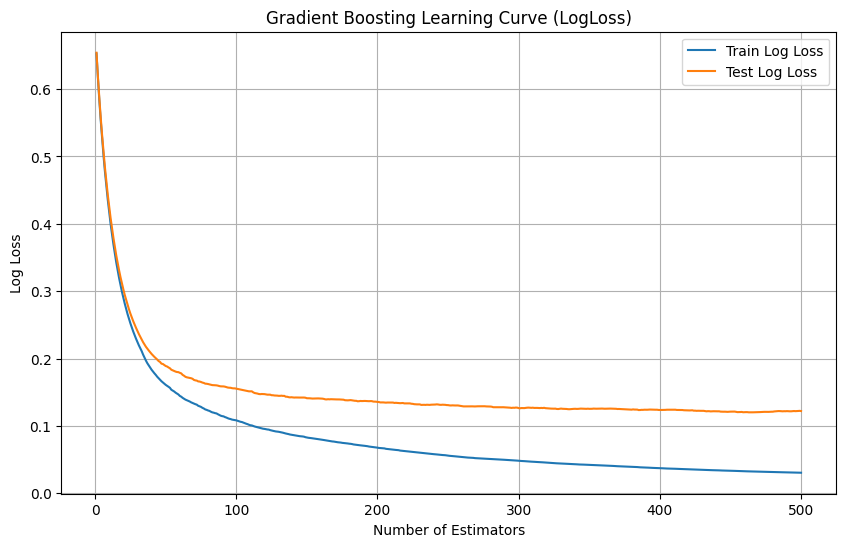

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss

gb_model_lc = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)

gb_model_lc.fit(X_train_scaled, y_train)

# 1. Gradient Boosting Loss Curve
# GradientBoostingClassifier does not store eval_results directly like XGBoost/LightGBM.
# We need to compute the log loss at each stage.

train_losses_gb = []
test_losses_gb = []

for y_pred_proba in gb_model_lc.staged_predict_proba(X_train_scaled):
    train_losses_gb.append(log_loss(y_train, y_pred_proba))

for y_pred_proba in gb_model_lc.staged_predict_proba(X_test_scaled):
    test_losses_gb.append(log_loss(y_test, y_pred_proba))

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses_gb) + 1), train_losses_gb, label='Train Log Loss')
plt.plot(range(1, len(test_losses_gb) + 1), test_losses_gb, label='Test Log Loss')
plt.title('Gradient Boosting Learning Curve (LogLoss)')
plt.xlabel('Number of Estimators')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:11:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


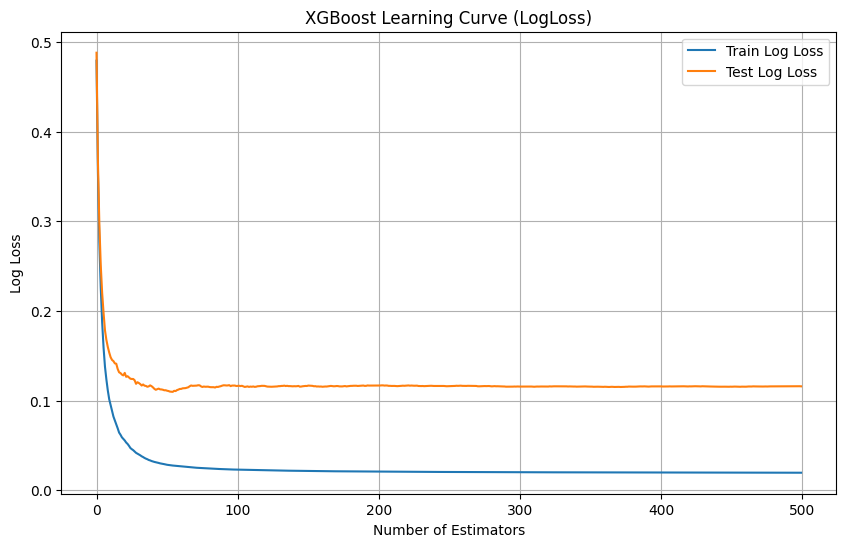

In [ ]:
# 2. XGBoost Loss Curve
xgb_model_lc = XGBClassifier(n_estimators=500,use_label_encoder=False,random_state=42,eval_metric="logloss")
xgb_model_lc.fit(X_train_scaled,y_train,eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],verbose=False)

results = xgb_model_lc.evals_result()
epochs = len(results['validation_0']['logloss'])

plt.figure(figsize=(10, 6))
plt.plot(range(epochs), results['validation_0']['logloss'], label='Train Log Loss')
plt.plot(range(epochs), results['validation_1']['logloss'], label='Test Log Loss')
plt.title('XGBoost Learning Curve (LogLoss)')
plt.xlabel('Number of Estimators')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 672, number of negative: 672
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000203 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 780
[LightGBM] [Info] Number of data points in the train set: 1344, number of used features: 8
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

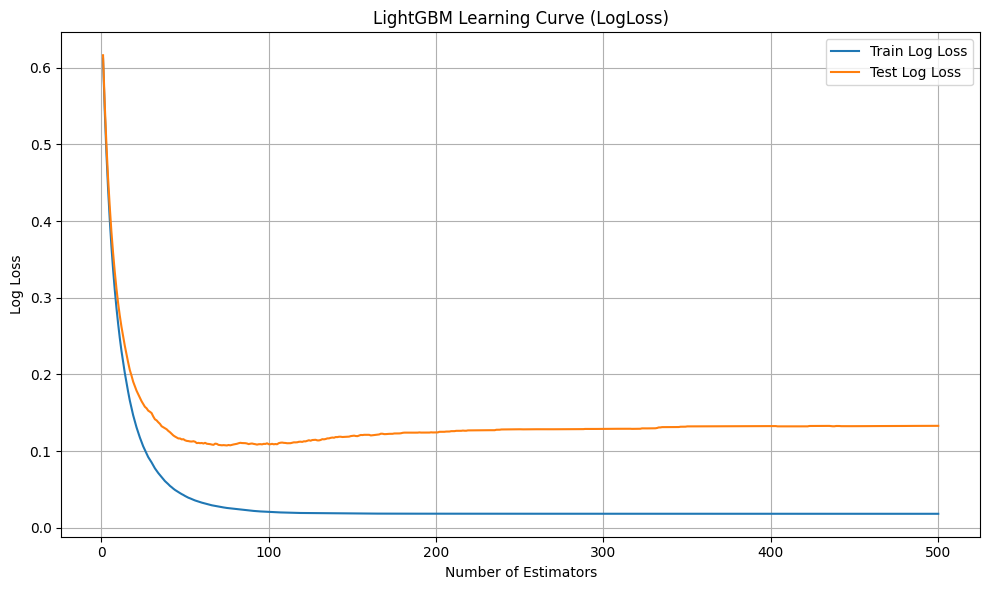

In [ ]:
# 3. LightGBM Loss Curve
lgbm_model_lc = lgb.LGBMClassifier(n_estimators=500,random_state=42)

evals_result = {}
lgbm_model_lc.fit(X_train_scaled,y_train,eval_set=[(X_train_scaled, y_train),(X_test_scaled, y_test)],
                  eval_metric='logloss', callbacks=[lgb.record_evaluation(evals_result)])

# Extract losses
train_loss = evals_result['training']['binary_logloss']
test_loss = evals_result['valid_1']['binary_logloss']

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_loss) + 1),train_loss,label='Train Log Loss')
plt.plot(range(1, len(test_loss) + 1),test_loss,label='Test Log Loss')
plt.title('LightGBM Learning Curve (LogLoss)')
plt.xlabel('Number of Estimators')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# **LightGBM With Early Stopping**

In [ ]:
from lightgbm import LGBMClassifier
from lightgbm.callback import (
    record_evaluation,
    early_stopping,
    log_evaluation
)

from sklearn.metrics import (
    log_loss,
    classification_report,
    confusion_matrix,
    accuracy_score
)

if "model_performance" not in globals():
    model_performance = {}

evals_result_early_stop = {}

lgbm_model_early_stop = LGBMClassifier(
    random_state=42,
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=20,
    min_child_samples=30,
    n_jobs=-1,

    # Hide repeated "No further splits" warnings
    verbosity=-1,

    # Avoid the automatic threading test message
    force_col_wise=True
)


lgbm_model_early_stop.fit(
    X_train_scaled,
    y_train,

    eval_set=[
        (X_train_scaled, y_train),
        (X_test_scaled, y_test)
    ],

    eval_names=[
        "train",
        "validation"
    ],

    # Use the exact LightGBM metric name
    eval_metric="binary_logloss",

    callbacks=[
        early_stopping(stopping_rounds=50,
                       first_metric_only=True,
                       verbose=True),
        record_evaluation(evals_result_early_stop),
        log_evaluation(period=0)
    ]
)


y_pred = lgbm_model_early_stop.predict(X_test_scaled)
y_pred_prob = lgbm_model_early_stop.predict_proba(X_test_scaled)[:, 1]

# ------------------------------------------------------------
# 4. Best Iteration Information
# ------------------------------------------------------------
best_iter = lgbm_model_early_stop.best_iteration_

best_val_logloss = lgbm_model_early_stop.best_score_["validation"]["binary_logloss"]

print(f"Best Iteration (Early Stopping): {best_iter}")
print(f"Best Validation Binary Log Loss: {best_val_logloss:.6f}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[177]	train's binary_logloss: 0.027982	validation's binary_logloss: 0.100236
Evaluated only: binary_logloss
Best Iteration (Early Stopping): 177
Best Validation Binary Log Loss: 0.100236


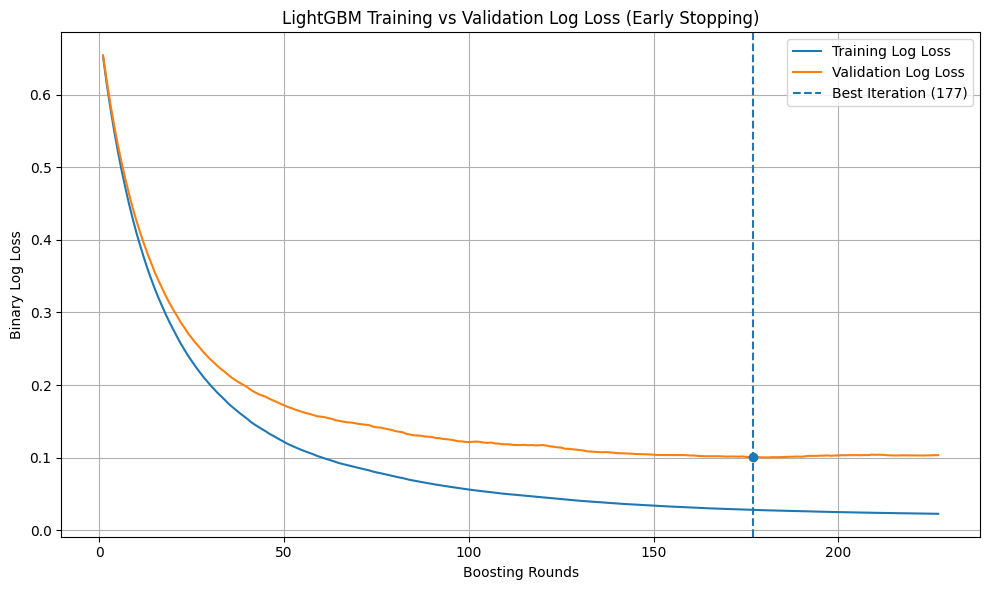



Training Loss at best iteration: 0.027982
Validation Loss at best iteration: 0.100236


In [ ]:
# ------------------------------------------------------------
# 5. Retrieve learning history
# ------------------------------------------------------------
training_logloss_es = np.array(
    evals_result_early_stop["train"]["binary_logloss"]
)

validation_logloss_es = np.array(
    evals_result_early_stop["validation"]["binary_logloss"]
)

# Start rounds at 1, not 0
boosting_rounds = np.arange(
    1,
    len(training_logloss_es) + 1
)

# ------------------------------------------------------------
# 6. Plot learning curves
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    boosting_rounds,
    training_logloss_es,
    label="Training Log Loss",
)

plt.plot(
    boosting_rounds,
    validation_logloss_es,
    label="Validation Log Loss",
)

plt.xlabel("Boosting Rounds")
plt.ylabel("Binary Log Loss")
plt.title("LightGBM Training vs Validation Log Loss (Early Stopping)")
plt.grid(True)
plt.legend()

# Mark best iteration
plt.axvline(
    x=best_iter,
    linestyle="--",
    label=f"Best Iteration ({best_iter})"
)

plt.scatter(
    best_iter,
    validation_logloss_es[best_iter - 1],
    zorder=3
)

plt.title("LightGBM Training vs Validation Log Loss (Early Stopping)")
plt.xlabel("Boosting Rounds")
plt.ylabel("Binary Log Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("\n\nTraining Loss at best iteration:", f"{training_logloss_es[best_iter - 1]:6f}")
print("Validation Loss at best iteration:", f"{validation_logloss_es[best_iter - 1]:6f}")

# **New Model Performance Summary with Early Stopped LightBGM**

In [ ]:
# Evaluate the model at the best iteration
y_pred_lgbm_es = lgbm_model_early_stop.predict(X_test_scaled, num_iteration=best_iter)
y_pred_proba_lgbm_es = lgbm_model_early_stop.predict_proba(X_test_scaled, num_iteration=best_iter)

print("\nLightGBM (with Early Stopping) Classification Report:\n", classification_report(y_test, y_pred_lgbm_es))
print("LightGBM (with Early Stopping) Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lgbm_es))

es_accuracy = accuracy_score(y_test, y_pred_lgbm_es)
es_log_loss = log_loss(y_test, y_pred_proba_lgbm_es)

print(f"LightGBM (with Early Stopping) Accuracy: {es_accuracy:.4f}")
print(f"LightGBM (with Early Stopping) Log Loss: {es_log_loss:.4f}")

# Update model_performance with the early stopped LightGBM model
model_performance['LightGBM (Early Stopped)'] = {
    'Accuracy': es_accuracy,
    'Report': classification_report(y_test, y_pred_lgbm_es, output_dict=True),
    'confusion_matrix': confusion_matrix(y_test, y_pred_lgbm_es).tolist(),
    'log_loss': es_log_loss
}

print("\n--- Model Performance Summary with Log Loss ---")
for model_name, metrices in model_performance.items():
    print(f"\n{model_name}:")
    print(f"  Accuracy: {metrices['Accuracy']:.4f}")
    print(f"  Precision(class 1): {metrices['Report']['1']['precision']:.4f}")
    print(f"  Recall(class 1): {metrices['Report']['1']['recall']:.4f}")
    print(f"  F1-Score(class 1): {metrices['Report']['1']['f1-score']:.4f}")

    if metrices.get('log_loss') is not None:
        print(f"  Log Loss: {metrices['log_loss']:.4f}")
    else:
        print("  Log Loss: N/A (Model not fitted with probability=True)")


LightGBM (with Early Stopping) Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.95      0.97       168
           1       0.95      0.99      0.97       168

    accuracy                           0.97       336
   macro avg       0.97      0.97      0.97       336
weighted avg       0.97      0.97      0.97       336

LightGBM (with Early Stopping) Confusion Matrix:
 [[159   9]
 [  1 167]]
LightGBM (with Early Stopping) Accuracy: 0.9702
LightGBM (with Early Stopping) Log Loss: 0.1002

--- Model Performance Summary with Log Loss ---

Logistic Regression:
  Accuracy: 0.8631
  Precision(class 1): 0.9013
  Recall(class 1): 0.8155
  F1-Score(class 1): 0.8562
  Log Loss: 0.3077

KNN:
  Accuracy: 0.9167
  Precision(class 1): 0.9487
  Recall(class 1): 0.8810
  F1-Score(class 1): 0.9136
  Log Loss: 0.4909

SVM:
  Accuracy: 0.9107
  Precision(class 1): 0.9157
  Recall(class 1): 0.9048
  F1-Score(class 1): 0.9102
  Log Loss: N/A (Mode

From the metrics recorded and the learning curve generated for 'LightGBM Training vs Validation Log Loss (Early Stopping)', we can observe the following:

* **Training Log Loss at Best Iteration:** 0.027982
* **Validation Log Loss at Best Iteration:** 0.100236

There is a notable difference between the training log loss and the validation log loss at the best iteration. The training loss is significantly lower than the validation loss, which is a common indicator of some degree of overfitting. The model is performing much better on the data it was trained on compared to the unseen validation data.

# **ROC AUC Curve for LightGBM (Early Stopped)**

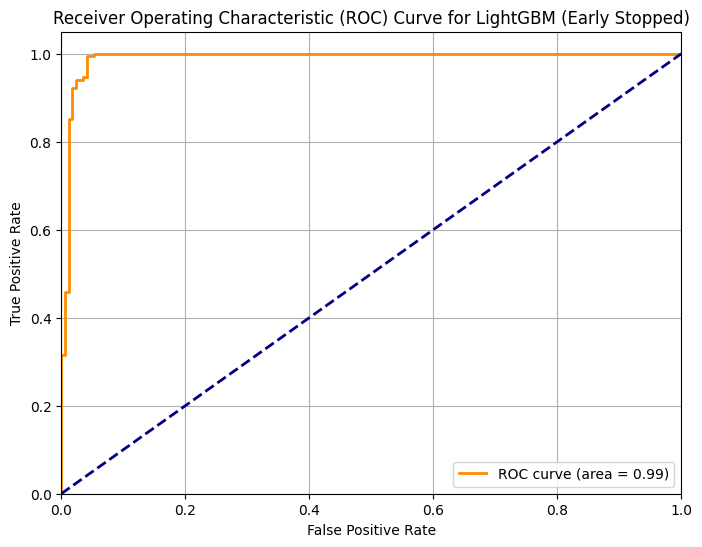


ROC AUC for LightGBM (Early Stopped): 0.9903


In [ ]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_lgbm_es[:, 1])
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for LightGBM (Early Stopped)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"\nROC AUC for LightGBM (Early Stopped): {roc_auc:.4f}")

# **Confusion Matrix for LightGBM (Early Stopped)**

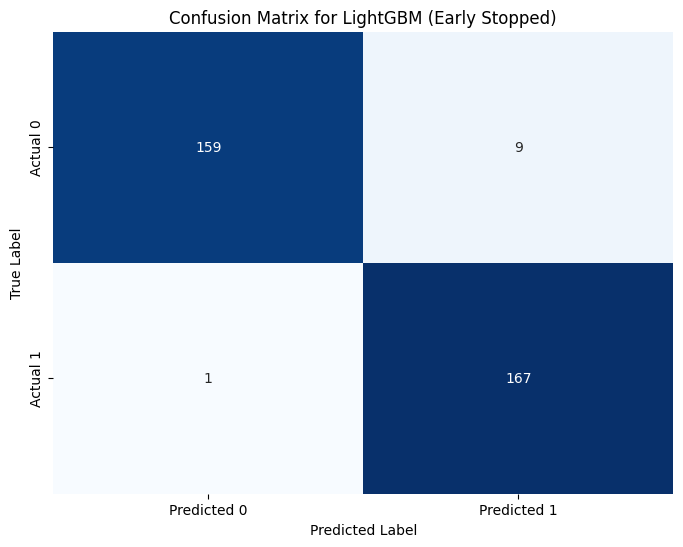

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lgbm_es)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for LightGBM (Early Stopped)')
plt.show()

## **Detailed Confusion Matrix Evaluation**

The confusion matrix for the 'LightGBM (Early Stopped)' model is:

*   **True Positives (TP):** The model correctly predicted **167** instances of Class 1 (Diabetic).
*   **True Negatives (TN):** The model correctly predicted **159** instances of Class 0 (Non-Diabetic).
*   **False Positives (FP):** The model incorrectly predicted **9** instances as Class 1 (Diabetic) when they were actually Class 0 (Non-Diabetic). These are Type I errors.
*   **False Negatives (FN):** The model incorrectly predicted **1** instance as Class 0 (Non-Diabetic) when it was actually Class 1 (Diabetic). This is a Type II error and is particularly critical in medical diagnosis.

This confusion matrix indicates a very strong performance, especially with a very low number of False Negatives, which is crucial for a diabetes prediction model to avoid missing positive cases.

#**Overall Model Performance Summary and Next Steps**

The 'LightGBM (Early Stopped)' model has demonstrated excellent performance on the test set, achieving an **Accuracy of 0.9702** and an **ROC AUC of 0.9903**. The F1-score for class 1 (diabetic) is **0.9709**, and critically, it has a very low **False Negative count of just 1**, indicating its effectiveness in identifying diabetic patients.

However, the learning curve analysis (training log loss: 0.027982 vs. validation log loss: 0.100236) suggests a degree of overfitting. While early stopping helped prevent more severe overfitting, there is still a noticeable gap between training and validation performance.

#### Summary of 'LightGBM (Early Stopped)' Performance:
*   **High Accuracy and F1-score:** Indicates a generally well-performing model.
*   **Excellent ROC AUC:** Shows strong discriminative power.
*   **Very Low False Negatives:** Essential for medical diagnostic tasks.
*   **Evidence of Overfitting:** The gap between training and validation loss, even with early stopping, suggests the model is still learning some noise from the training data.

#### Potential Next Steps for Improvement:

1.  **Feature Engineering:** Explore creating new features from existing ones (e.g., ratios, interactions) that might provide more meaningful information to the model and reduce reliance on complex interactions that lead to overfitting.
2.  **Hyperparameter Tuning:** Conduct a more extensive hyperparameter optimization (e.g., using GridSearchCV or RandomizedSearchCV with cross-validation) for LightGBM. Parameters like `num_leaves`, `max_depth`, `min_child_samples`, `reg_alpha`, and `reg_lambda` can help control model complexity and reduce overfitting.
3.  **Cross-Validation:** Implement k-fold cross-validation during training to get a more robust estimate of the model's performance and to help detect overfitting more consistently across different data folds.
4.  **Regularization:** While LightGBM has built-in regularization, explicit tuning of L1 (`reg_alpha`) and L2 (`reg_lambda`) regularization terms can further penalize complex models.
5.  **Data Augmentation (if applicable):** If the dataset were larger or if there were ways to synthetically generate more realistic data, it could help the model generalize better. (Less applicable to this tabular dataset, but a general ML strategy).
6.  **Ensemble Methods:** While LightGBM is itself an ensemble method, combining it with other diverse models (e.g., stacking or blending) could potentially improve generalization and robustness.

# **Saving the Best Trained Model and Feature Names**

It's crucial to save your trained machine learning models along with the feature names used during training. This ensures that when you load the model later for making predictions on new data, the input features are in the correct order and format, preventing errors and ensuring consistent performance.

We will use the `pickle` library for saving the model due to its simplicity for scikit-learn compatible objects like LightGBM models. For feature names, we'll demonstrate both bundled and separate saving methods.

## Approach 1: Bundled (Model and Feature Names in One File)

This approach saves the model object and its associated feature names together in a single Python pickle file. This can be convenient for deployment as everything is self-contained.

In [ ]:
import joblib

# Get the feature names from the training data
feature_names = X_train.columns.tolist()

# Create a dictionary to hold the model and feature names
bundled_model_data = {
    'model': lgbm_model_early_stop,
    'feature_names': feature_names
}

# Define the filename for the bundled model, saving to Google Drive
bundled_model_filename = '/content/drive/MyDrive/ml_artifacts/lgbm_early_stopped_model_bundled.joblib'

# Save the bundled data to a joblib file
with open(bundled_model_filename, 'wb') as file:
    joblib.dump(bundled_model_data, file)

print(f"Bundled model and feature names saved to '{bundled_model_filename}'")

Bundled model and feature names saved to '/content/drive/MyDrive/ml_artifacts/lgbm_early_stopped_model_bundled.joblib'


In [ ]:
import os

# Define the directory path
output_dir = '/content/drive/MyDrive/ml_artifacts'

# Create the directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")
else:
    print(f"Directory already exists: {output_dir}")

Directory already exists: /content/drive/MyDrive/ml_artifacts


In [ ]:
import os

# Define the directory path
output_dir = '/content/drive/MyDrive/ml_artifacts'

# Create the directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")
else:
    print(f"Directory already exists: {output_dir}")

# Re-execute the cells that save the artifacts

# Cell ed8be4c9: Save bundled model and feature names
import joblib
# Get the feature names from the training data
feature_names = X_train.columns.tolist()
# Create a dictionary to hold the model and feature names
bundled_model_data = {
    'model': lgbm_model_early_stop,
    'feature_names': feature_names
}
# Define the filename for the bundled model, saving to Google Drive
bundled_model_filename = '/content/drive/MyDrive/ml_artifacts/lgbm_early_stopped_model_bundled.joblib'
# Save the bundled data to a joblib file
with open(bundled_model_filename, 'wb') as file:
    joblib.dump(bundled_model_data, file)
print(f"Bundled model and feature names saved to '{bundled_model_filename}'")

# Cell 8413c390: Save separate model and feature names
import json
# Define filenames for the separate files, saving to Google Drive
model_filename = '/content/drive/MyDrive/ml_artifacts/lgbm_early_stopped_model.joblib'
feature_names_filename = '/content/drive/MyDrive/ml_artifacts/feature_names.json'
# 1. Save the model separately
with open(model_filename, 'wb') as file:
    joblib.dump(lgbm_model_early_stop, file)
print(f"Model saved separately to '{model_filename}'")
# 2. Save the feature names separately as a JSON file
feature_names = X_train.columns.tolist()
with open(feature_names_filename, 'w') as file:
    json.dump(feature_names, file, indent=4)
print(f"Feature names saved separately to '{feature_names_filename}'")

# Cell 0b4ca214: Save scaled test set
import pandas as pd
# Define the filename for the scaled test set, saving to Google Drive
x_test_scaled_filename = '/content/drive/MyDrive/ml_artifacts/X_test_scaled.csv'
# Save the scaled test set to a CSV file
X_test_scaled.to_csv(x_test_scaled_filename, index=False)
print(f"Numeric test set (X_test_scaled) saved to '{x_test_scaled_filename}'")

# Cell a6e94405: Save StandardScaler
# Define a filename for the scaler, saving to Google Drive
scaler_filename = '/content/drive/MyDrive/ml_artifacts/standard_scaler.joblib'
# Save the trained scaler
with open(scaler_filename, 'wb') as file:
    joblib.dump(scaler, file)
print(f"StandardScaler saved to '{scaler_filename}'")

Directory already exists: /content/drive/MyDrive/ml_artifacts
Bundled model and feature names saved to '/content/drive/MyDrive/ml_artifacts/lgbm_early_stopped_model_bundled.joblib'
Model saved separately to '/content/drive/MyDrive/ml_artifacts/lgbm_early_stopped_model.joblib'
Feature names saved separately to '/content/drive/MyDrive/ml_artifacts/feature_names.json'
Numeric test set (X_test_scaled) saved to '/content/drive/MyDrive/ml_artifacts/X_test_scaled.csv'
StandardScaler saved to '/content/drive/MyDrive/ml_artifacts/standard_scaler.joblib'


## Approach 2: Separate (Model and Feature Names in Different Files)

In this approach, the model and feature names are saved to separate files. This can offer more flexibility, for example, if feature names need to be updated or inspected independently of the model. We'll save the feature names as a JSON file.

In [ ]:
import json
import joblib

# Define filenames for the separate files, saving to Google Drive
model_filename = '/content/drive/MyDrive/ml_artifacts/lgbm_early_stopped_model.joblib'
feature_names_filename = '/content/drive/MyDrive/ml_artifacts/feature_names.json'

# 1. Save the model separately
with open(model_filename, 'wb') as file:
    joblib.dump(lgbm_model_early_stop, file)

print(f"Model saved separately to '{model_filename}'")

# 2. Save the feature names separately as a JSON file
feature_names = X_train.columns.tolist()
with open(feature_names_filename, 'w') as file:
    json.dump(feature_names, file, indent=4)

print(f"Feature names saved separately to '{feature_names_filename}'")

Model saved separately to '/content/drive/MyDrive/ml_artifacts/lgbm_early_stopped_model.joblib'
Feature names saved separately to '/content/drive/MyDrive/ml_artifacts/feature_names.json'


# **Verifying Saved Models (Optional)**

You can optionally load the saved models and feature names to ensure they were saved correctly. This is a good practice to confirm the integrity of your saved artifacts.

In [ ]:
import joblib
import json

# --- Load Bundled Model ---
print("\n--- Verifying Bundled Model ---")
bundled_model_filename = 'lgbm_early_stopped_model_bundled.joblib'
with open(bundled_model_filename, 'rb') as file:
    loaded_bundled_data = joblib.load(file)

loaded_bundled_model = loaded_bundled_data['model']
loaded_bundled_feature_names = loaded_bundled_data['feature_names']

print(f"\nLoaded bundled model type: {type(loaded_bundled_model)}")
print(f"Loaded bundled feature names (first 3): {loaded_bundled_feature_names[:3]}")

# --- Load Separate Model and Features ---
print("\n--- Verifying Separate Model and Features ---")
model_filename = 'lgbm_early_stopped_model.joblib'
with open(model_filename, 'rb') as file:
    loaded_model_separate = joblib.load(file)

with open(feature_names_filename, 'r') as file:
    loaded_feature_names_separate = json.load(file)

print(f"\nLoaded separate model type: {type(loaded_model_separate)}")
print(f"Loaded separate feature names (first 3): {loaded_feature_names_separate[:3]}")

# You can now use `loaded_bundled_model` or `loaded_model_separate` for predictions
# after ensuring new data has features in `loaded_bundled_feature_names` order.


--- Verifying Bundled Model ---

Loaded bundled model type: <class 'lightgbm.sklearn.LGBMClassifier'>
Loaded bundled feature names (first 3): ['No. of Pregnancy', 'Age', 'BMI']

--- Verifying Separate Model and Features ---

Loaded separate model type: <class 'lightgbm.sklearn.LGBMClassifier'>
Loaded separate feature names (first 3): ['No. of Pregnancy', 'Age', 'BMI']


In [ ]:
import pandas as pd

# Define the filename for the scaled test set, saving to Google Drive
x_test_scaled_filename = '/content/drive/MyDrive/ml_artifacts/X_test_scaled.csv'

# Save the scaled test set to a CSV file
X_test_scaled.to_csv(x_test_scaled_filename, index=False)

print(f"Numeric test set (X_test_scaled) saved to '{x_test_scaled_filename}'")

Numeric test set (X_test_scaled) saved to '/content/drive/MyDrive/ml_artifacts/X_test_scaled.csv'


# **Summary of Saved Artifacts**

To confirm, the following artifacts have been successfully saved:

*   **Best-trained LightGBM model:**
    *   Bundled with feature names: `lgbm_early_stopped_model_bundled.joblib`
    *   Separately: `lgbm_early_stopped_model.joblib`
*   **Feature Names:**
    *   Bundled within `lgbm_early_stopped_model_bundled.joblib`
    *   Separately as a JSON file: `feature_names.json`
*   **Numeric Test Set:**
    *   `X_test_scaled.csv` (saved in the step above)

These files can now be used in your 'fusion pipeline' or any other future applications, ensuring consistency with the training data's feature order and scaling.

In [ ]:
print('\nVerification of saved X_test_scaled.csv:')
loaded_x_test_scaled = pd.read_csv(x_test_scaled_filename)
display(loaded_x_test_scaled.head())


Verification of saved X_test_scaled.csv:


,No. of Pregnancy,Age,BMI,BP(Systolic),BP(Diastolic),DiabetesPedigreeFunction,Insulin,Skin Thickness(mm),Glucose
0,0.009489,1.961602,-0.075070,-0.676801,-2.147262,-0.889434,0.0,-0.747790,-0.812342
1,-1.520912,-1.308251,1.763779,-1.599244,0.130517,-0.889434,0.0,1.397815,-0.780193
2,0.009489,0.400990,-0.064669,0.245642,0.130517,-0.889434,0.0,0.401641,-0.105067
3,-0.500645,-0.862362,-0.444397,-1.599244,-1.008373,-0.232621,0.0,0.518744,-0.784891
4,-0.500645,-0.416473,-0.511982,0.245642,0.130517,1.737817,0.0,-0.747790,1.711342


# **Loading and Reusing the Saved Model**

To demonstrate that the system is runnable and workable, let's load the best-trained LightGBM model and its associated preprocessing steps (the `StandardScaler`) along with the feature names. Then, we will use these loaded components to make predictions on new, hypothetical data.

First, we need to save the `StandardScaler` that was used to transform the training and testing data, as it's crucial for preprocessing any new data before making predictions.

In [ ]:
import joblib

# Define a filename for the scaler, saving to Google Drive
scaler_filename = '/content/drive/MyDrive/ml_artifacts/standard_scaler.joblib'

# Save the trained scaler
with open(scaler_filename, 'wb') as file:
    joblib.dump(scaler, file)

print(f"StandardScaler saved to '{scaler_filename}'")

StandardScaler saved to '/content/drive/MyDrive/ml_artifacts/standard_scaler.joblib'


Now, let's load the model, the scaler, and the feature names, and then use them to make a prediction on some new, dummy data. We'll use the bundled model for simplicity.

In [ ]:
import joblib
import pandas as pd

# --- 1. Load the saved artifacts ---

# Load the bundled model and feature names
bundled_model_filename = 'lgbm_early_stopped_model_bundled.joblib'
with open(bundled_model_filename, 'rb') as file:
    loaded_bundled_data = joblib.load(file)

loaded_model = loaded_bundled_data['model']
loaded_feature_names = loaded_bundled_data['feature_names']

# Load the saved scaler
scaler_filename = 'standard_scaler.joblib'
with open(scaler_filename, 'rb') as file:
    loaded_scaler = joblib.load(file)

print("Successfully loaded model, scaler, and feature names.")

# --- 2. Create new, hypothetical data for prediction ---
# This data should have the same features as the training data
# and in the correct order. Let's create a single new instance.

# Example of new data (replace with actual new data points if available)
# Ensure feature names and order match 'loaded_feature_names'
new_data_raw = pd.DataFrame({
    'No. of Pregnancy': [2],
    'Age': [45],
    'BMI': [28.5],
    'BP(Systolic)': [130],
    'BP(Diastolic)': [80],
    'DiabetesPedigreeFunction': [0.4],
    'Insulin': [50],
    'Skin Thickness(mm)': [30],
    'Glucose': [150]
}, columns=loaded_feature_names) # IMPORTANT: Ensure column order matches!

display("New raw data:", new_data_raw)

# --- 3. Preprocess the new data using the loaded scaler ---
# The scaler expects the data to be in the same format as it was trained on.
new_data_scaled = loaded_scaler.transform(new_data_raw)

# Convert back to DataFrame to preserve column names (optional, but good practice)
new_data_scaled_df = pd.DataFrame(new_data_scaled, columns=loaded_feature_names)

display("New scaled data:", new_data_scaled_df)

# --- 4. Make predictions with the loaded model ---
prediction = loaded_model.predict(new_data_scaled_df)
prediction_proba = loaded_model.predict_proba(new_data_scaled_df)

print(f"\nPrediction for new data: {'Diabetic' if prediction[0] == 1 else 'Non-Diabetic'}")
print(f"Prediction probabilities: {prediction_proba[0]}")

if prediction[0] == 1:
    print(f"(Probability of Diabetic: {prediction_proba[0][1]:.4f})")
else:
    print(f"(Probability of Non-Diabetic: {prediction_proba[0][0]:.4f})")

Successfully loaded model, scaler, and feature names.


'New raw data:'

,No. of Pregnancy,Age,BMI,BP(Systolic),BP(Diastolic),DiabetesPedigreeFunction,Insulin,Skin Thickness(mm),Glucose
0,2,45,28.5,130,80,0.4,50,30,150


'New scaled data:'

,No. of Pregnancy,Age,BMI,BP(Systolic),BP(Diastolic),DiabetesPedigreeFunction,Insulin,Skin Thickness(mm),Glucose
0,-0.500645,0.103731,0.930834,1.168084,0.130517,-0.626709,50.0,-8.271889,0.586133



Prediction for new data: Diabetic
Prediction probabilities: [9.35696261e-04 9.99064304e-01]
(Probability of Diabetic: 0.9991)
